# Average Multiple Days Together

## Imports and Versions

In [85]:
from pygsdata import GSData
from pathlib import Path

from edges_cal import modelling as mdl

from edges_analysis.averaging.lstbin import average_over_times
from edges_analysis.datamodel import add_model
from edges_analysis.filters.filters import rfi_model_filter
from edges_cal.alanmode import read_spec_txt
from pygsdata import plots
import matplotlib.pyplot as plt
import numpy as np
from edges_pipelines import utils
from edges_analysis.filters import filters
from pygsdata import GSFlag

from pygsdata.register import gsregister
from edges_analysis.filters.filters import gsdata_filter, rms_filter
from typing import Literal
from astropy import units as u
from edges_analysis.averaging import averaging
from edges_analysis.averaging.utils import NsamplesStrategy

from edges_analysis.averaging.combiners import average_files_pairwise, average_multiple_objects
from edges_analysis.datamodel import add_model
from edges_cal.modelling.models import PhysicalLin


import sys
# Add the folder to sys.path
folder_path = Path("/data4/vydula/edges/edges3-data-analysis/scripts/")
sys.path.append(str(folder_path))

import plotting_tools as e3plt

In [2]:
plt.style.use("default")

In [3]:
utils.print_versions()


Versions: 
            read_acq: 1.1.1.dev6+gb1a6b4d
            pygsdata: 0.2.2.dev6+ge6726b0
           edges-cal: 7.1.0
            edges-io: 4.1.9.dev5+g08d3eed
      edges-analysis: 6.0.3.dev96+gf2b3739


## Parameters and Data Loading

In [4]:
datadir: str = "/data4/vydula/edges/edges3-data-analysis/scripts/prefect-10days/prefect-outputs"
nightly_files: list[str] = [Path(f"{datadir}/2023_{day}.finalspec.gsh5") for day in range(300, 309)]


In [ ]:
del nightly_files[4] #diesn't have all entries

In [5]:
datadir = Path(datadir)

In [6]:
data = [GSData.from_file(d) for d in nightly_files]

In [30]:
#some of these files don't have all the entries, so filtering out
# Get the shapes of all loaded data
shapes = [d.data.shape for d in data]

# Determine the most common shape
from collections import Counter
shape_counts = Counter(shapes)
most_common_shape = shape_counts.most_common(1)[0][0]

# Filter out data that doesn't match the most common shape
filtered_data = [d for d in data if d.data.shape == most_common_shape]

# (Optional) If you want to exclude files with inconsistent shapes from `nightly_files`:
filtered_files = [
    f for d, f in zip(data, nightly_files) if d.data.shape == most_common_shape
]

In [29]:
len(filtered_files), len(data)

(8, 9)

In [31]:
data_with_model = [add_model(d, nsamples_strategy='flagged-nsamples-uniform',
                             model= PhysicalLin(
                                 spectral_index =-2.55, 
                                 f_center= 85, 
                                 n_terms =5)) for d in filtered_data]

In [8]:
# fig, ax = plt.subplots(len(data), 1, sharex=True, constrained_layout=True, figsize=(5, 20))
# for i in range(len(data)):
#     plots.plot_waterfall(data_with_model[i], attribute='data',vmin=0, vmax=10000, ax= ax[i], xlab= False) 

    

## Analysis and Averaging

### Model the spectra so we can average residuals only

When we perform the average over nights, we average the models and residuals separately (and the residuals receive frequency-dependent weights while the models do not). First, we model each night here.

### Some Filters

Our first filter is an RMS filter (just thresholding a whole night based on its RMS to the fitted model)

In [10]:
rms_data = [rms_filter(d, threshold=0.17, nsamples_strategy='flagged-nsamples-uniform') for d in data_with_model]

2023_301 was fully flagged during rms_filter filter
2023_304 was fully flagged during rms_filter filter


In [11]:
# #assert np.sum(~rms_data.flags['rms_filter'].flags[0,0] ^ alanfilt[:, 1].astype(bool))==0
# rms_data = filters.prune_flagged_integrations(rms_data)
# print(rms_data.ntimes)

Based on the model already fit, we perform simple RFI-flagging, where we flag any channel whose residual is larger than a threshold multiplied by the RMS of the residuals that night (over frequency).

In [12]:
@filters.gsdata_filter()
def rms_rfi_filter(data: GSData, threshold):
    
    
    ns = (data.nsamples[0,0] > 0).astype(float)

    sumn = np.sum(ns, axis=1)
    sumres = np.sum(data.residuals[0,0]**2 * ns, axis=1)
    rms = np.sqrt(np.where(sumn > 0, sumres / sumn, 0))[None, None, :, None]

    return GSFlag(flags=data.residuals > rms * threshold, axes=("load", "pol", "time", "freq"))

In [13]:
#[np.all(d.complete_flags) for d in rms_data]

In [32]:

filt_data = [rms_rfi_filter(d, threshold=1.9) for d in data_with_model]


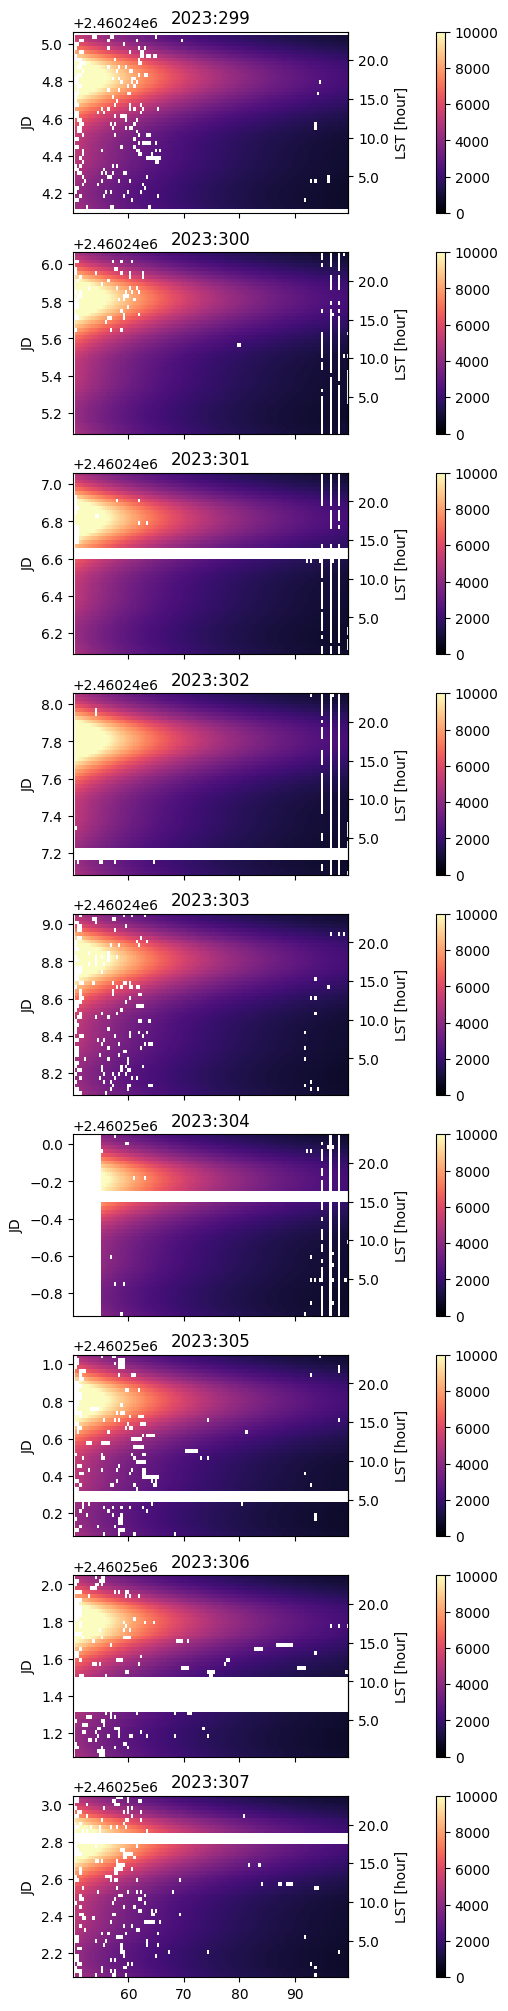

In [15]:
fig, ax = plt.subplots(len(filt_data), 1, sharex=True, constrained_layout=True, figsize=(5, 20))
for i in range(len(filt_data)):
    plots.plot_waterfall(filt_data[i], attribute='data',vmin=0, vmax=10000, ax= ax[i], xlab= False)

### Average all nights

In [40]:
avg_data = average_files_pairwise(*filtered_files, 
             use_resids=True, 
             nsamples_strategy = NsamplesStrategy.FLAGGED_NSAMPLES_UNIFORM
                                  )

In [49]:
avg_filtered = filt_data[0]
for i in range(len(filt_data)-1):
    
    avg_filtered = average_multiple_objects(filt_data[i], filt_data[i+1], use_resids=True, 
                                    nsamples_strategy = NsamplesStrategy.FLAGGED_NSAMPLES_UNIFORM)
    

<Figure size 500x600 with 0 Axes>

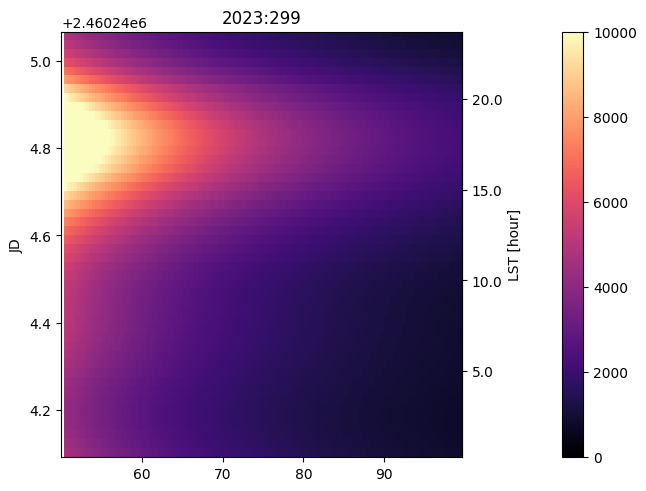

In [42]:
plt.figure(figsize=(5, 6))
plots.plot_waterfall(avg_data, attribute='data',vmin=0, vmax=10000, xlab= False)
plt.show()

<Figure size 500x600 with 0 Axes>

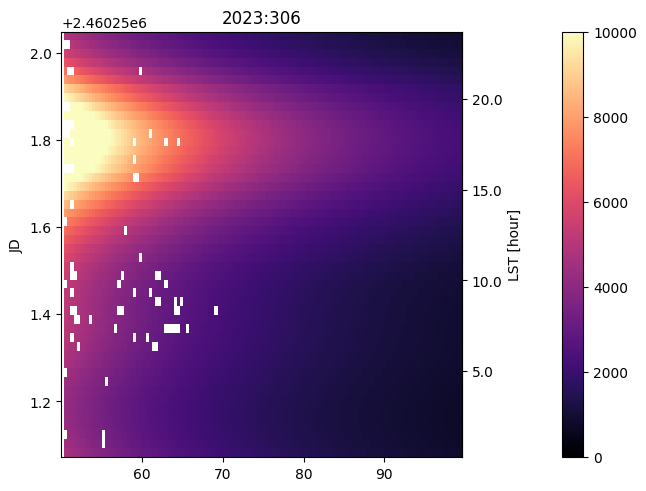

In [50]:
plt.figure(figsize=(5, 6))
plots.plot_waterfall(avg_filtered, attribute='data',vmin=0, vmax=10000, xlab= False)
plt.show()

### Last RFI Filter

In [51]:
final_data = add_model(avg_data, model=mdl.LinLog(n_terms=5))
final_data_filtered = add_model(avg_filtered, model=mdl.LinLog(n_terms=5))

## Inspect Final Results

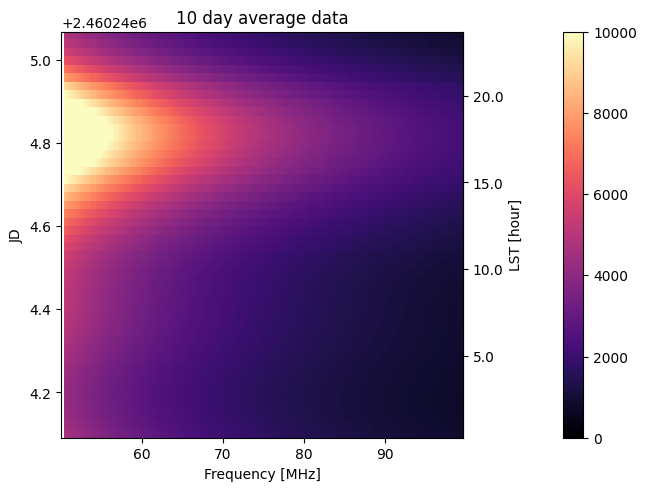

(<Axes: title={'center': '10 day average data'}, xlabel='Frequency [MHz]', ylabel='JD'>,
 <matplotlib.colorbar.Colorbar at 0x7fbb7fa3fc50>)

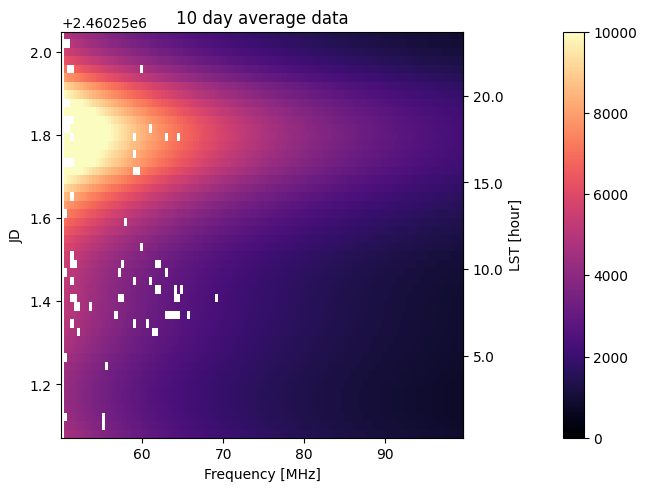

In [52]:
plots.plot_waterfall(final_data, attribute='data',vmin=0, vmax=10000, title='10 day average data')
plt.show()
plots.plot_waterfall(final_data_filtered, attribute='data',vmin=0, vmax=10000, title='10 day average data')

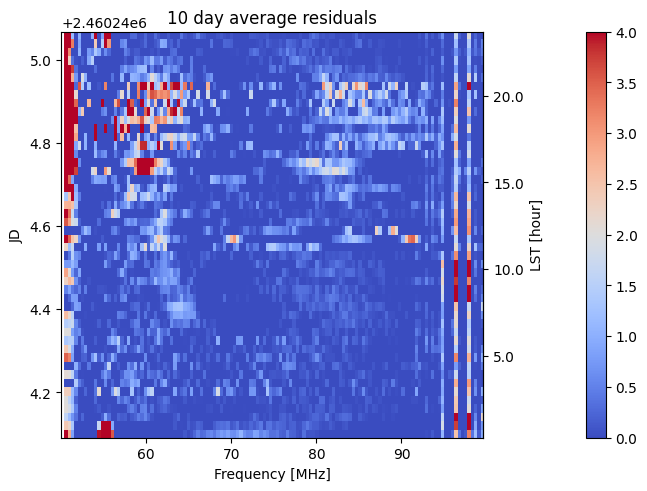

(<Axes: title={'center': '10 day average residuals'}, xlabel='Frequency [MHz]', ylabel='JD'>,
 <matplotlib.colorbar.Colorbar at 0x7fbb7fc7d490>)

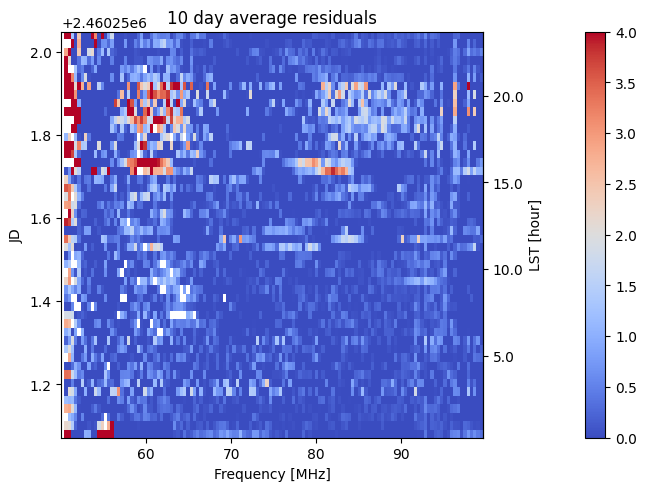

In [53]:
plots.plot_waterfall(final_data, attribute='residuals', vmin=0, vmax=4,title='10 day average residuals')
plt.show()
plots.plot_waterfall(final_data_filtered, attribute='residuals', vmin=0, vmax=4,title='10 day average residuals')

Text(0.95, 0.9, 'FG Residuals (LinLog, 5-term)')

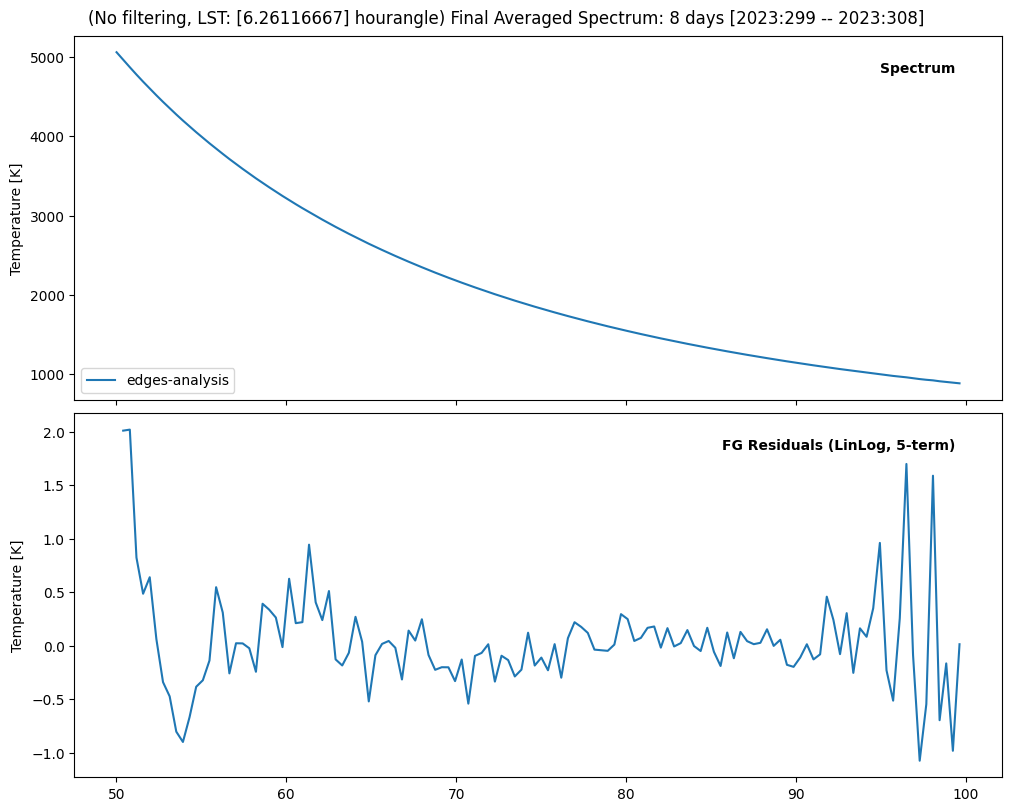

In [78]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8), constrained_layout=True)

#ax[0].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, final_data.data[0,0,0], np.nan), label='edges-analysis')
ax[0].plot(final_data.freqs,final_data.data[0,0,12], label='edges-analysis')

ax[0].legend()

ax[0].text(0.95, 0.9, "Spectrum", transform=ax[0].transAxes, ha='right', fontweight='bold')

for i in range(2):
    ax[i].set_ylabel("Temperature [K]")
    
ttmin = filtered_data[0].times.min().datetime.timetuple()
ttmax = filtered_data[-1].times.max().datetime.timetuple()

fig.suptitle(f"(No filtering, LST: {final_data.lsts[12]}) Final Averaged Spectrum: {len(filtered_files)} days [{ttmin.tm_year}:{ttmin.tm_yday:>03} -- {ttmax.tm_year}:{ttmax.tm_yday:>03}]")

ax[1].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,12]>0, final_data.residuals[0,0,12], np.nan))

ax[1].text(0.95, 0.9, "FG Residuals (LinLog, 5-term)", transform=ax[1].transAxes, ha='right', fontweight='bold')




Text(0.95, 0.9, 'FG Residuals (LinLog, 5-term)')

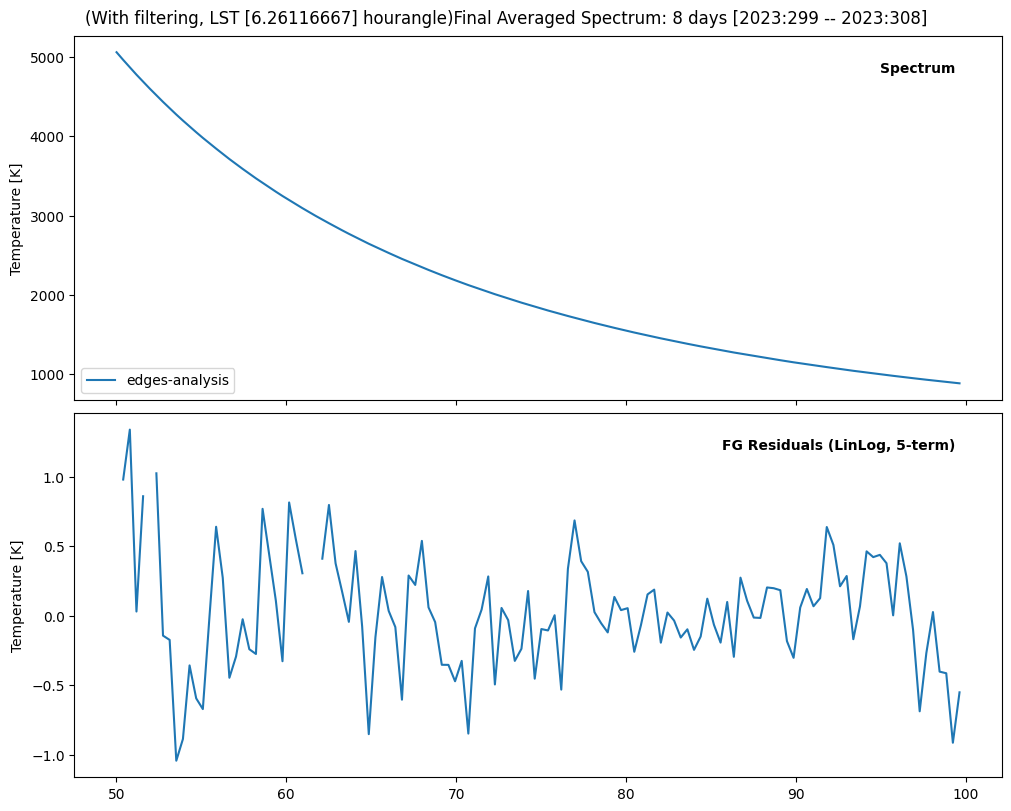

In [79]:
fig, ax = plt.subplots(2, 1, sharex=True, figsize=(10, 8), constrained_layout=True)

#ax[0].plot(final_data.freqs, np.where(final_data.flagged_nsamples[0,0,0]>0, final_data.data[0,0,0], np.nan), label='edges-analysis')
ax[0].plot(final_data.freqs,final_data_filtered.data[0,0,12], label='edges-analysis')

ax[0].legend()

ax[0].text(0.95, 0.9, "Spectrum", transform=ax[0].transAxes, ha='right', fontweight='bold')

for i in range(2):
    ax[i].set_ylabel("Temperature [K]")
    
ttmin = filtered_data[0].times.min().datetime.timetuple()
ttmax = filtered_data[-1].times.max().datetime.timetuple()

fig.suptitle(f"(With filtering, LST {final_data_filtered.lsts[12]})Final Averaged Spectrum: {len(filtered_files)} days [{ttmin.tm_year}:{ttmin.tm_yday:>03} -- {ttmax.tm_year}:{ttmax.tm_yday:>03}]")

ax[1].plot(final_data.freqs, np.where(final_data_filtered.flagged_nsamples[0,0,12]>0, final_data_filtered.residuals[0,0,12], np.nan))

ax[1].text(0.95, 0.9, "FG Residuals (LinLog, 5-term)", transform=ax[1].transAxes, ha='right', fontweight='bold')




## Write out the data

In [80]:
final_data_filtered.write_gsh5(Path(datadir) / "averaged_spectrum.gsh5");

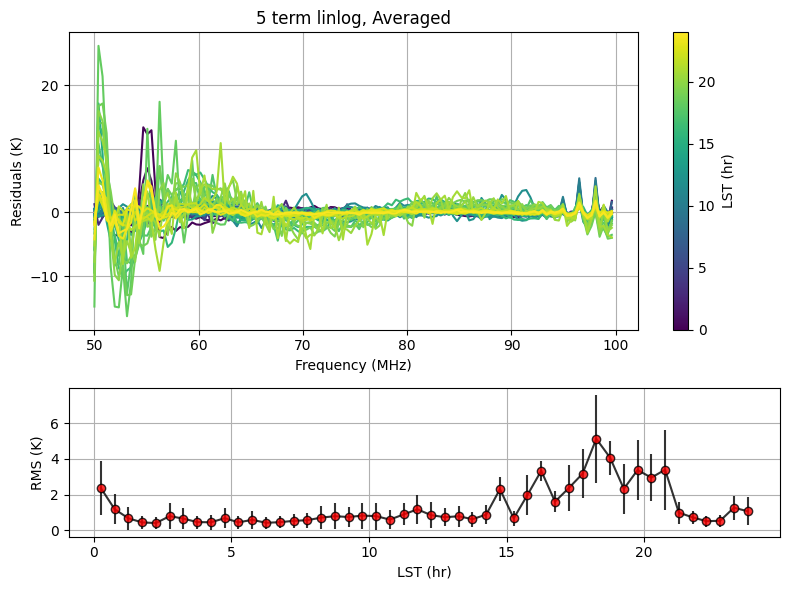

In [115]:
e3plt.plot_rms_lst(final_data, figsave = None);

In [116]:
import edges_analysis.averaging.combiners as comb

In [ ]:
comb.